## Data Cleaning

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import missingno as msno

In [2]:
# Load dataset
df = pd.read_csv(".csv/SBAnational.csv")

/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_56182/1549966169.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(".csv/SBAnational.csv")


In [3]:
# Make copy of dataset
wdf = df.copy()

In [5]:
# Check data types
wdf.dtypes

LoanNr_ChkDgt          int64
Name                  object
City                  object
State                 object
Zip                    int64
Bank                  object
BankState             object
NAICS                  int64
ApprovalDate          object
ApprovalFY            object
Term                   int64
NoEmp                  int64
NewExist             float64
CreateJob              int64
RetainedJob            int64
FranchiseCode          int64
UrbanRural             int64
RevLineCr             object
LowDoc                object
ChgOffDate            object
DisbursementDate      object
DisbursementGross     object
BalanceGross          object
MIS_Status            object
ChgOffPrinGr          object
GrAppv                object
SBA_Appv              object
dtype: object

<Axes: >

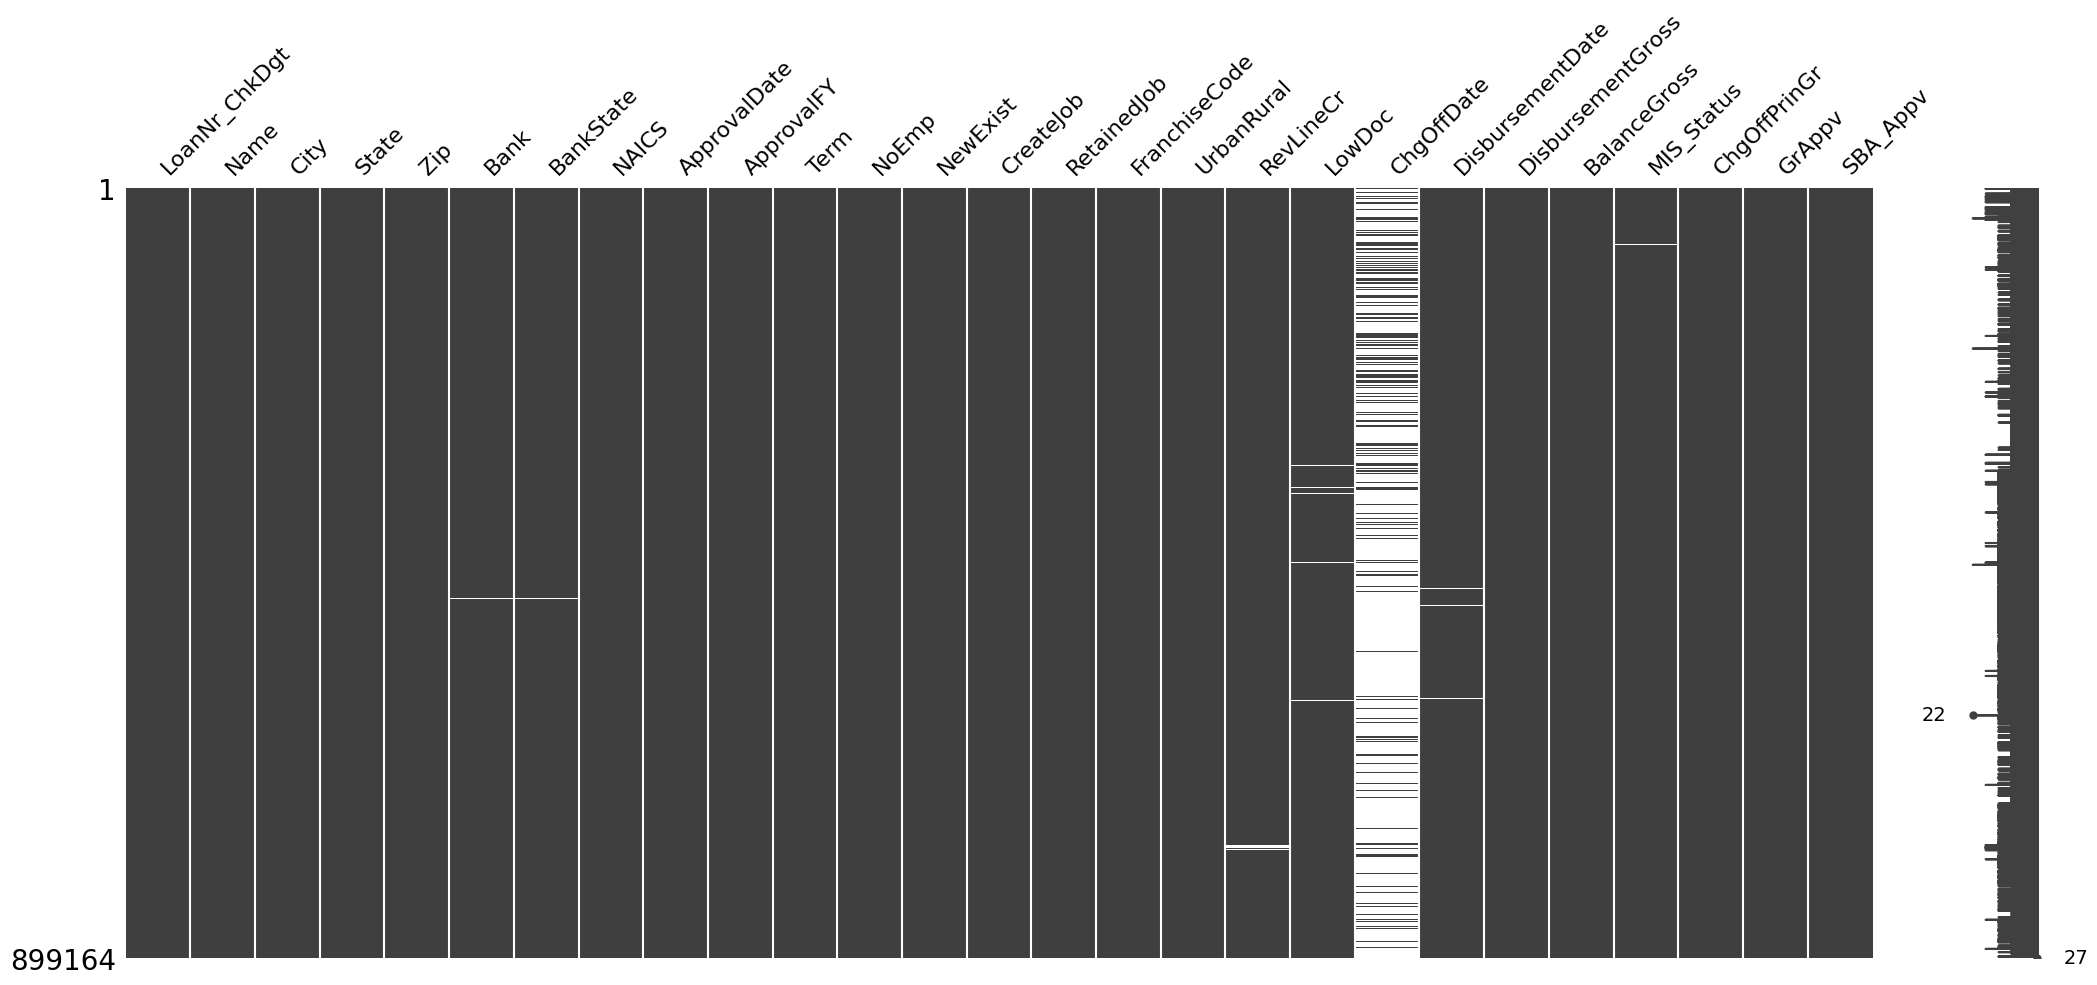

In [6]:
# View missing values matrix
msno.matrix(wdf)

In [7]:
# View columns (and the number of rows) with missing values
wdf.isna().sum()

LoanNr_ChkDgt             0
Name                     14
City                     30
State                    14
Zip                       0
Bank                   1559
BankState              1566
NAICS                     0
ApprovalDate              0
ApprovalFY                0
Term                      0
NoEmp                     0
NewExist                136
CreateJob                 0
RetainedJob               0
FranchiseCode             0
UrbanRural                0
RevLineCr              4528
LowDoc                 2582
ChgOffDate           736465
DisbursementDate       2368
DisbursementGross         0
BalanceGross              0
MIS_Status             1997
ChgOffPrinGr              0
GrAppv                    0
SBA_Appv                  0
dtype: int64

### String and Numerical Data manipulations

- Convert columns with monetary values to integer

In [8]:
# Convert columns with monetary values to integers by removing decimal places and dollar signs
# to standardize the format and optimize storage for calculations.

list_monetary_integers = ['DisbursementGross', 'GrAppv', 'BalanceGross', 'SBA_Appv', 'ChgOffPrinGr']

wdf[list_monetary_integers] = round(wdf[list_monetary_integers].replace(r'[$, ]', '', regex=True).astype(float).astype(int), 2)

In [9]:
# Replace values without "Y" or "N" with NA
wdf['LowDoc'] = wdf['LowDoc'].replace(r'[0CSAR1]',np.nan, regex=True)

### Dealing with missing values

- Clean by 'Name' column

In [10]:
# Check rows with missing name data
check_missing_name = wdf[wdf['Name'].isna()]

# check_missing_name

In [11]:
# Input unknown for rows with missing name data
wdf['Name'] = wdf['Name'].fillna('UNKNOWN NAME')

- Clean by 'City' column

In [12]:
# Check rows with missing city data
check_missing_city = wdf[wdf['City'].isna()]

# check_missing_city.head()

In [13]:
# View the zip code of rows with missing city data
check_missing_city['Zip'].unique()

array([84109, 70130, 60624, 60636, 92102, 44115, 63103, 63105, 63013,
       98104, 50309, 78204, 64106,  2169,  2108,  2401,  2165, 40209,
       28402, 48502])

In [14]:
# Create a dictionary to input city data based on zip code
zip_city = [84109, 70130, 60624, 60636, 
            92102, 44115, 63103, 63105, 
            63013, 98104, 50309, 78204, 
            64106,  2169,  2108,  2401,  
            2165, 40209, 28402, 48502]

city_code = ['SALT LAKE CITY', 'NEW ORLEANS', 'CHICAGO', 'CHICAGO', 
             'SAN DIEGO', 'CLEVELAND', 'ST. LOUIS', 'ST. LOUIS', 
             'BEAUFORT', 'SEATTLE', 'DES MOINES', 'SAN ANTONIO',
             'KANSAS CITY', 'BOSTON', 'BOSTON', 'FALL RIVER',
             'BOSTON', 'LOUISVILLE', 'WILMINGTON', 'FLINT']

# Create a dictionary to map zip code to city
zip_city_dict = dict(zip(zip_city, city_code))

# Input city data based on zip code
for key, value in zip_city_dict.items():
    wdf.loc[(wdf['Zip'] == key) & (wdf['City'].isna()), 'City'] = value

- Clean by 'State' column

In [15]:
# Check rows with missing state data
check_missing_state = wdf[wdf['State'].isna()]

# check_missing_state

In [16]:
# View the zip code of rows with missing state data 
check_missing_state['Zip'].unique()

array([ 8070,     0, 95682, 96205, 67219, 79925, 33410, 54205, 54025,
       84124, 65049, 75236, 76052, 76645])

In [17]:
# Create a dictionary to input state data based on zip code (state for zip code with O value is determined by its city)
state_zipcode = [8070, 0, 95682, 96205, 67219, 
                79925, 33410, 54205, 54025, 
                84124, 65049, 75236, 76052, 
                76645]

state_code = ['NJ', 'NY', 'CA', 'CA', 'KS',
              'TX', 'FL', 'WI', 'WI',
              'UT', 'MO', 'TX', 'TX',
              'TX']

# Create a dictionary to map city name to state
state_city_dict = dict(zip(state_zipcode, state_code))

# Input state data based on city name
for key, value in state_city_dict.items():
    wdf.loc[(wdf['Zip'] == key) & (wdf['State'].isna()), 'State'] = value

- Clean by 'Bank' column

In [18]:
# Check rows with missing bank data
check_missing_bank = wdf[wdf['Bank'].isna()]

# check_missing_bank.head()

In [19]:
# Input unknown for rows with missing bank data
wdf['Bank'] = wdf['Bank'].fillna('UNKNOWN BANK')

- Clean by 'BankState' column

In [20]:
# Check rows with missing bankstate data
check_missing_bank_state = wdf[wdf['BankState'].isna()]

# check_missing_bank_state.head()

In [21]:
# Input unknown for rows with missing bankstate data
wdf['BankState'] = wdf['BankState'].fillna('UB')

- Clean by 'NewExist' column

In [22]:
check_missing_newexist = wdf[wdf['NewExist'].isna()]

# check_missing_newexist.head()

In [23]:
# Input NaN for rows with missing NewExist data
wdf['NewExist'] = wdf['NewExist'].replace({0.0: np.nan})

# The NaNs are not filled or deleted because they will be managed by the chosen model

- Clean by 'RevLineCr' column

In [24]:
# Input NaN for rows with "other" values in the RevLineCr' data
wdf['RevLineCr'] = wdf['RevLineCr'].replace(r'[0T1R`2C,37A5.4Q\-]', np.nan, regex=True)

# The NaNs are not filled or deleted because they will be managed by the chosen model

-  Clean by 'LowDoc' column

In [25]:
# Update only NaN values in LowDoc based on GrAppv
wdf["LowDoc"] = wdf.apply(lambda row: "Y" if pd.isna(row["LowDoc"]) and row["GrAppv"] <= 150000 else "N" if pd.isna(row["LowDoc"]) else row["LowDoc"], axis=1)

- Clean by 'UrbanRural' column

In [26]:
# Input NaN for rows with missing UrbanRural data
wdf['UrbanRural'] = wdf['UrbanRural'].replace({0: np.nan})

- Clean by 'MIS_STATUS'

In [27]:
# Remove spaces in 'MIS_STATUS' column
wdf['MIS_Status'] = wdf['MIS_Status'].apply(lambda x: str(x).replace(" ", ""))

In [28]:
# Relace nans with NaNs
wdf['MIS_Status'] = np.where(wdf['MIS_Status'] == "nan", np.nan, wdf['MIS_Status'])

In [29]:
# Update missing values based on 'ChgOffDate' column
wdf.loc[
    wdf['MIS_Status'].isna() & wdf['ChgOffDate'].notna(), 
    'MIS_Status'
] = "CHGOFF"

- Clean by 'ChgOffDate' column

In [30]:
# Replace 'ChgOffDate' with a default date '01-Jan-1970' if missing
wdf['ChgOffDate'] = np.where(wdf['ChgOffDate'].isna(), pd.to_datetime('01-Jan-1970', format='%d-%b-%Y'), wdf['ChgOffDate'])

### Create New Columns

- Map NAICS code to actvity type

In [31]:
# Get the first two digits of the NAICS code
wdf['NAICS_class_code'] = wdf['NAICS'].apply(lambda x: int(str(x)[:2]) if pd.notna(x) and len(str(x)) >= 2 else 81)

In [32]:
# Map NAICS code to industry
wdf['Industry'] = wdf['NAICS_class_code'].map({
    11: "Agriculture, forestry, fishing and hunting",
    21: "Mining, Quarrying, and oil and gas extraction",
    22: "Utilities",
    23: "Construction",
    31: "Manufacturing",
    32: "Manufacturing",
    33: "Manufacturing",
    42: "Wholesale trade",
    44: "Retail trade",
    45: "Retail trade",
    48: "Transportation and warehousing",
    49: "Transportation and warehousing",
    51: "Information",
    52: "Finance and insurance",
    53: "Real estate and rental and leasing",
    54: "Professional, scientific, and technical services",
    55: "Management of companies and enterprises",
    56: "Administrative and support and waste management and remediation services",
    61: "Educational services",
    62: "Health care and social assistance",
    71: "Arts, enternaiment, and recreation",
    72: "Accommodation and food services",
    81: "Other services", 
    92: "Public administration",
    })

- Encode FranchiseCode

In [33]:
# Map 'FranchiseCode' to binary values
wdf['FranchiseCode_Encoded'] = wdf['FranchiseCode'].apply(lambda x: 'Yes' if x > 1 else 'No')

- Add Real Estate Backed Loans

In [34]:
# Map 'Term' to binary values
wdf['RealEstate_Backed'] = wdf['Term'].apply(lambda x: "Yes" if x >= 240 else "No")

-  Convert Date columns to DateTime object

In [35]:
wdf['ApprovalDate'] = pd.to_datetime(wdf['ApprovalDate'], errors='ignore', format='%d-%b-%y')
wdf['ChgOffDate'] = pd.to_datetime(wdf['ChgOffDate'], errors='ignore', format='%d-%b-%y')

/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_17205/1911448850.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  wdf['ApprovalDate'] = pd.to_datetime(wdf['ApprovalDate'], errors='ignore', format='%d-%b-%y')
/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_17205/1911448850.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  wdf['ChgOffDate'] = pd.to_datetime(wdf['ChgOffDate'], errors='ignore', format='%d-%b-%y')


In [36]:
# Extract year from 'ApprovalDate' and 'ChgOffDate' columns
wdf['ApprovalDateYear'] = wdf['ApprovalDate'].dt.year
wdf['ChgOffDateYear'] = wdf['ChgOffDate'].dt.year

In [37]:
# Extract month from 'ApprovalDate' columns
wdf['ApprovalDateMonth'] = wdf['ApprovalDate'].dt.month

In [38]:
# Convert 'ApprovalFY' to string
wdf['ApprovalFY'] = wdf['ApprovalFY'].apply(lambda x: str(x).strip()[:4])

# Convert 'ApprovalFY' to datetime format
wdf['ApprovalFY'] = pd.to_datetime(wdf['ApprovalFY'], errors='raise', format='mixed')

# Extract year from 'ApprovalFY' column
wdf['ApprovalFY'] = wdf['ApprovalFY'].dt.year

In [39]:
# Remove spaces in 'DisbursementDate' column
wdf['DisbursementDate'] = wdf['DisbursementDate'].apply(lambda x: str(x).strip())

# Convert 'DisbursementDate' to datetime format
wdf['DisbursementDate'] = pd.to_datetime(wdf['DisbursementDate'], errors='ignore',format='%d-%b-%y')

wdf['DisbursementDate'] =  wdf['DisbursementDate'].replace(np.nan, pd.to_datetime('01-Jan-1970', format='%d-%b-%Y'))

wdf['DisbursementDateYear'] = wdf['DisbursementDate'].dt.year

/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_17205/1024855919.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  wdf['DisbursementDate'] = pd.to_datetime(wdf['DisbursementDate'], errors='ignore',format='%d-%b-%y')


- Encode 'State' column

In [40]:
# Check unique values in 'State' column
all_states = wdf['State'].unique()

# Group states into regions
northern_states_in_all_states = ['ME', 'NH', 'VT', 'MA', 'CT', 'RI', 'NY', 'PA', 'NJ', 'DE', 'MD', 'DC']
western_satates_in_all_starts = ['WA', 'OR', 'CA', 'NV', 'ID', 'MT', 'WY', 'UT', 'CO', 'AZ', 'NM', 'AK', 'HI']
eastern_states_in_all_states = ['ND', 'SD', 'NE', 'KS', 'MN', 'IA', 'MO', 'WI', 'IL', 'IN', 'MI', 'OH', 'KY', 'WV', 'VA', 'NC', 'SC', 'TN', 'AR', 'OK', 'LA', 'MS', 'AL', 'GA', 'FL']
southern_states_in_all_states = ['TX']

# Create a new column 'Region' to group states into regions
wdf['Region'] = wdf['State'].apply(lambda x: 'Northern' if x in northern_states_in_all_states else ('Western' if x in western_satates_in_all_starts else ('Eastern' if x in eastern_states_in_all_states else 'Southern')))

- Encode to determine "Recession"

In [41]:
# Convert 'Term' to days
wdf["TermDays"] = wdf['Term'] * 30

# Calculate 'LoanDateEnd' by adding 'TermDays' to 'DisbursementDate'
wdf["LoanDateEnd"] = wdf['DisbursementDate'] + pd.to_timedelta(wdf['TermDays'], unit='D')

In [42]:
# Define the recession period
recession_start = pd.to_datetime('2007-12-01')
recession_end = pd.to_datetime('2009-06-30')

# Create a new column 'Reccession' to indicate if the loan was disbursed during the recession period
wdf['Recession'] = np.where((wdf['LoanDateEnd'] >= recession_start) & (wdf['LoanDateEnd'] <= recession_end), 1, 0)

In [43]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_colum', None)
pd.set_option('display.max_row', None)

- Encode 'EmployeeLoanRatio' based on 'GrAppv' & 'NoEmp' columns

In [81]:
wdf['EmployeeLoanRatio'] = round(wdf['GrAppv'] / wdf['NoEmp'],2).astype(float)

- Encode 'StateRisk' based on State CHGOFF Count

In [77]:
# Select States with ChgOff status
chgoff_states = wdf.loc[wdf['MIS_Status'] == 'CHGOFF', ['MIS_Status', 'State']]

# Group by State
state_by_chrgoff_count = chgoff_states.groupby('State').size().reset_index(name='Count')

# Sort Values by Count
state_by_chrgoff_count = state_by_chrgoff_count.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Encode States based on Count
state_by_chrgoff_count['StateRisk'] = state_by_chrgoff_count['Count'].apply(lambda x: "High" if x > 10000 else("Medium" if 2000 < x < 10000 else "Low"))

# Rank States based on Count
high_risk_states = state_by_chrgoff_count.loc[state_by_chrgoff_count['StateRisk'] == 'High', 'State'].to_list()
medium_risk_states = state_by_chrgoff_count.loc[state_by_chrgoff_count['StateRisk'] == 'Medium', 'State'].to_list()
low_risk_states = state_by_chrgoff_count.loc[state_by_chrgoff_count['StateRisk'] == 'Low', 'State'].to_list()

In [79]:
# Create StateRisk column
wdf['StateRisk'] = wdf['State'].apply(lambda x: "High" if x in high_risk_states else("Medium" if x in medium_risk_states else "Low"))


### Save cleaned data

In [84]:
# Specify target column with missing rows
rows_with_missing_values = ['MIS_Status']

# Filter dataset to only include rows without missing target values
wdf = wdf[wdf[rows_with_missing_values].notna().all(axis=1)]

In [87]:
wdf.to_csv('cleaned_data.csv', index=True)